In [1]:
from langgraph.graph import StateGraph, START, END

from typing_extensions import TypedDict, NotRequired

from spm_agent.states.image_analysis_state import ImageAnalysisState

from spm_agent.nodes.readfile_node import readfile_node
from spm_agent.nodes.channel_recommendation_node import channel_recommendation_node
from spm_agent.nodes.agentic_segmentation_node import agentic_segmentation_node
from spm_agent.nodes.set_experiment_tasks_node import make_experiment_tasks_node
from spm_agent.nodes.importance_map_node import importance_map_node


In [2]:
EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    "Compare switching inside domains vs near domain walls",
    "Study wall-mediated switching"
]

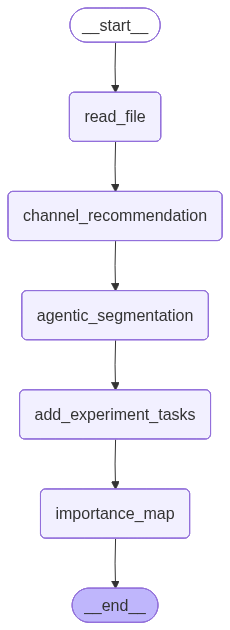

In [3]:
builder = StateGraph(ImageAnalysisState)
builder.add_node("read_file", readfile_node)
builder.add_node("channel_recommendation", channel_recommendation_node)
builder.add_node("agentic_segmentation", agentic_segmentation_node)
builder.add_node("add_experiment_tasks", make_experiment_tasks_node(EXPERIMENT_TASKS)) # type: ignore
builder.add_node("importance_map", importance_map_node)

builder.add_edge(START, "read_file")
builder.add_edge("read_file", "channel_recommendation")
builder.add_edge("channel_recommendation", "agentic_segmentation")
builder.add_edge("agentic_segmentation", "add_experiment_tasks")
builder.add_edge("add_experiment_tasks", "importance_map")
builder.add_edge("importance_map", END)

im_graph = builder.compile()
im_graph

In [4]:
result = await im_graph.ainvoke(
    {
        "file_path": r"/Users/borisslautin/Documents/!!UTK/agentic_SPM/exp_files/PLZT_0001.ibw",
    }
)

In [5]:
# --- Cell: importance-map visualization helpers ---
import numpy as np
import matplotlib.pyplot as plt


def _view01(a, p=(1, 99)):
    """Robust [0,1] view of a channel for use as a grayscale backdrop."""
    a = a.astype(float); f = a[np.isfinite(a)]
    lo, hi = np.percentile(f, p) if f.size else (0.0, 1.0)
    return np.clip((a - lo) / (hi - lo + 1e-12), 0, 1)


def show_importance_map(result, ax=None):
    """Bare heatmap of one importance map, titled by its experiment task."""
    m = np.load(result["importance_map_path"])
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(m, cmap="inferno", vmin=0, vmax=100)
    ax.set_title(result["experiment_task"], fontsize=9)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="importance")
    return ax


def compare_importance_maps(results):
    """All maps side by side — quick way to see they differ per task."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    axes = np.atleast_1d(axes)
    for ax, r in zip(axes, results):
        show_importance_map(r, ax=ax)
    plt.tight_layout(); plt.show()


def show_importance_over_channel(result, channel_array_path, mask_paths=None, alpha=0.55):
    """Channel grayscale + importance heatmap overlaid, with optional mask contours."""
    ch = _view01(np.load(channel_array_path))
    m  = np.load(result["importance_map_path"])
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(ch, cmap="gray")
    im = ax.imshow(np.ma.masked_less(m, 1), cmap="inferno", vmin=0, vmax=100, alpha=alpha)
    for mp in (mask_paths or []):
        ax.contour(np.load(mp).astype(float), levels=[0.5], colors="cyan", linewidths=0.6)
    ax.set_title(result["experiment_task"], fontsize=9); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="importance")
    plt.show()


def region_importance(result, mask_paths: dict):
    """Mean importance per named region, e.g. {'domain': path, 'wall': path}. + background."""
    m = np.load(result["importance_map_path"])
    masks = {k: np.load(v).astype(bool) for k, v in mask_paths.items()}
    out = {k: (round(float(m[mk].mean()), 1) if mk.any() else None) for k, mk in masks.items()}
    bg = ~np.logical_or.reduce(list(masks.values())) if masks else np.ones_like(m, bool)
    out["background"] = round(float(m[bg].mean()), 1)
    return out


def show_top_peaks(result, channel_array_path, k=5, min_sep=15):
    """Preview of the deferred deterministic pick: greedy top-k peaks with a pixel min-separation."""
    m = np.load(result["importance_map_path"]); mm = m.copy()
    H, W = m.shape; yy, xx = np.ogrid[:H, :W]; pts = []
    for _ in range(k):
        r, c = np.unravel_index(np.argmax(mm), mm.shape)
        pts.append((int(r), int(c)))
        mm[(yy - r) ** 2 + (xx - c) ** 2 <= min_sep ** 2] = -1
    ch = _view01(np.load(channel_array_path))
    fig, ax = plt.subplots(figsize=(6, 6)); ax.imshow(ch, cmap="gray")
    ax.imshow(np.ma.masked_less(m, 1), cmap="inferno", vmin=0, vmax=100, alpha=0.5)
    for i, (r, c) in enumerate(pts):
        ax.plot(c, r, "o", mfc="none", mec="cyan", ms=14, mew=2)
        ax.text(c + 4, r, str(i + 1), color="cyan", fontsize=9)
    ax.set_title(f"{result['experiment_task']} — top {k}", fontsize=9); ax.axis("off"); plt.show()
    return pts

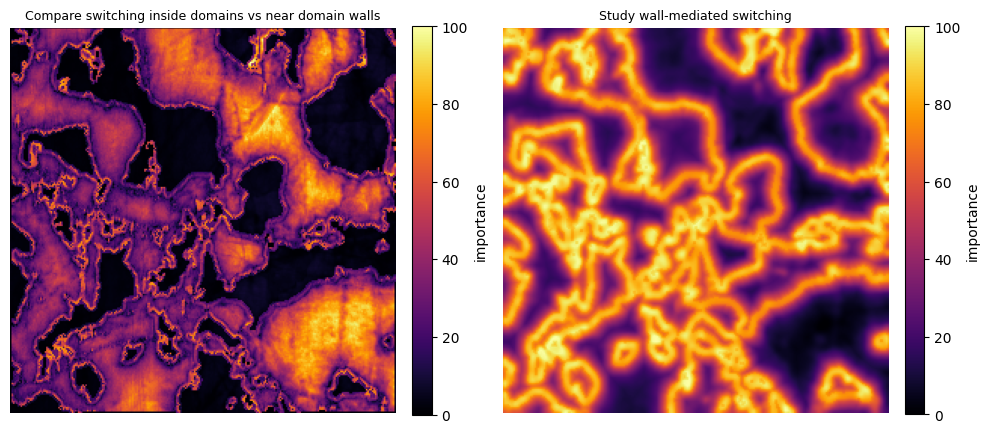

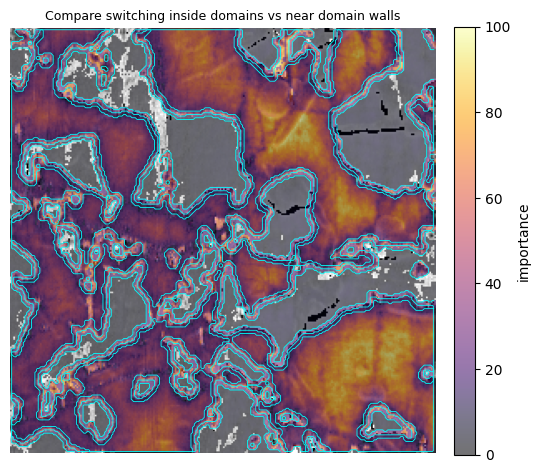

map_0 by region: {'domain': 42.2, 'wall': 32.8, 'background': 2.8}
map_1 by region: {'domain': 47.1, 'wall': 84.3, 'background': 51.5}


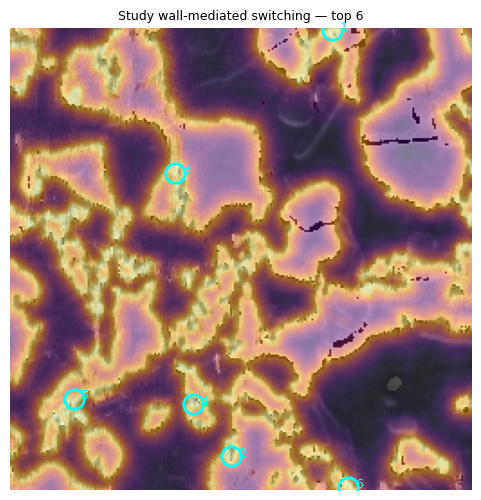

[(1, 178), (237, 122), (80, 91), (208, 101), (205, 35), (254, 187)]

In [6]:
# --- Cell: usage (paths from state, cwd-independent) ---
maps     = result["importance_maps"]
channels = result["file_channels"]
seg      = result["segmentation_results"]

phase = channels["Channel_003"]["array_path"]                       # absolute
dom   = seg["ferroelectric domain segmentation"]["mask_path"]       # absolute
wall  = seg["ferroelectric domain wall segmentation"]["mask_path"]  # absolute

compare_importance_maps(maps)
show_importance_over_channel(maps[0], phase, mask_paths=[dom, wall])
print("map_0 by region:", region_importance(maps[0], {"domain": dom, "wall": wall}))
print("map_1 by region:", region_importance(maps[1], {"domain": dom, "wall": wall}))
show_top_peaks(maps[1], phase, k=6, min_sep=15)

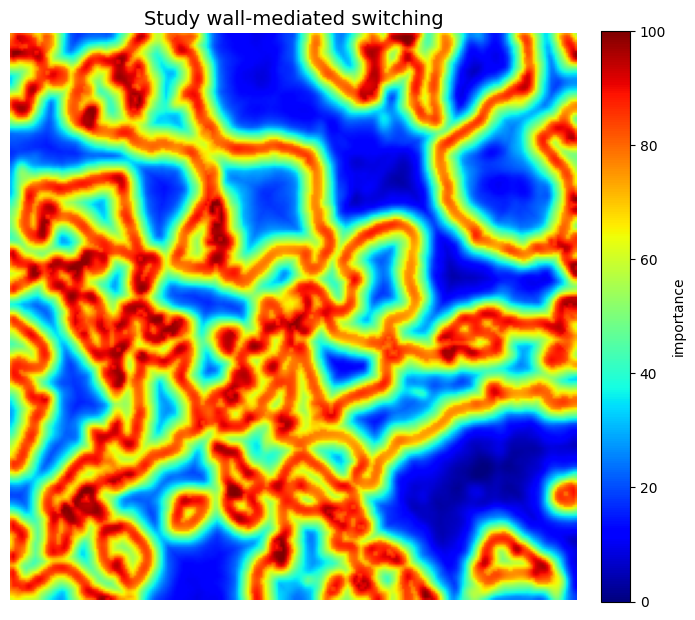

In [20]:

j = 1
m = np.load(result['importance_maps'][j]['importance_map_path'])

_, ax = plt.subplots(figsize=(8,8))
im = ax.imshow(m, cmap="jet", vmin=0, vmax=100)
ax.set_title(result['importance_maps'][j]['experiment_task'], fontsize=14)
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="importance")

In [8]:
from IPython.display import display, Markdown

def show_reasoning(result):
    display(Markdown(f"### {result['experiment_task']}\n\n{result['reasoning']}"))

for r in maps:
    show_reasoning(r)

### Compare switching inside domains vs near domain walls

The importance map is well-structured and saved. Here is the summary of the criteria used:

---

**Criteria and Rationale:**

The task is to compare ferroelectric switching *inside domains* vs. *near domain walls*, so the importance map must highlight high-quality measurement sites in **both** regions independently, then combine them.

1. **PFM Amplitude (Channels 1 & 2, averaged)** — The primary signal quality indicator. High piezoelectric amplitude means a strong, reliable switching response can be measured. Low-amplitude pixels (e.g., at grain boundaries or defects) yield noisy switching loops and are deprioritized.

2. **Phase clarity (Channel 4 / Phase2)** — For domain interior sites, pixels with a well-defined polarization state (phase far from the ambiguous midpoint between the two domain states) are preferred. These represent "clean" single-domain regions where the baseline switching coercive field can be unambiguously measured.

3. **Distance from domain wall** — Domain interior candidates are further rewarded for being well away from walls, ensuring the measurement is not contaminated by wall-pinning effects and truly represents bulk domain switching.

4. **Phase gradient** — For wall sites, a large local phase gradient confirms the presence of a genuine polarization transition, making these the most informative wall locations for studying wall-assisted or wall-pinned switching.

5. **Wall proximity (Gaussian-smoothed wall mask)** — Softly weights wall-region pixels by how centrally they sit within the segmented wall band, ensuring the highest scores go to the wall core rather than its fringes.

Each region (domain interior, domain wall) was scored and scaled independently to the full 0–100 range, then combined via pixel-wise maximum, so both region types compete equally for measurement slots.

### Study wall-mediated switching

The `importance_map.npy` is saved, valid, and ready. Here is the reasoning:

---

**Criteria and rationale for wall-mediated switching:**

1. **Domain wall proximity (w = 0.35):** Wall-mediated switching is initiated at or immediately adjacent to domain walls. An exponential decay (σ ≈ 8 px) from the segmented wall pixels ensures the highest scores sit on the walls themselves, with a smooth halo extending into the flanking domains — exactly where nucleation events propagate from the wall.

2. **Phase2 gradient magnitude (w = 0.25):** Sharp spatial gradients in the out-of-plane PFM phase (Channel_004, the channel used for segmentation) mark genuine, well-defined polarization boundaries. High-gradient locations are the most structurally distinct walls and therefore the most informative sites for probing switching thresholds.

3. **PFM Amplitude2 suppression (w = 0.15):** At domain walls the two antiparallel polarization contributions partially cancel, producing a local dip in PFM amplitude. Pixels with low Amplitude2 co-located with wall regions confirm a true electromechanical wall node — the most relevant site for measuring switching fields.

4. **Wall geometric complexity (w = 0.15):** A local wall-density metric (uniform filter, 15 px window) peaks at intermediate values corresponding to curved, branching, or narrow wall segments. These geometrically complex sections have lower pinning energy barriers and are preferential nucleation sites for wall-mediated switching.

5. **Phase1 vs Phase2 discordance (w = 0.10):** Regions where the two PFM phase channels disagree indicate mixed or metastable polarization states — candidate locations for incomplete switching or coexisting phases, which are particularly interesting for studying the switching mechanism.

In [21]:
result['segmentation_results']['ferroelectric domain segmentation'].keys()

dict_keys(['task', 'channel', 'mask_path', 'overlay_path', 'n_regions', 'coverage', 'ops', 'reasoning', 'vision_in_loop', 'model', 'n_look'])

In [19]:
display(Markdown(f"### {result['segmentation_results']['ferroelectric domain segmentation']['task']}\n\n\n{result['segmentation_results']['ferroelectric domain segmentation']['reasoning']}"))

### ferroelectric domain segmentation


The mask cleanly captures the light-gray ferroelectric domains (red overlay) while excluding the dark domains (black). The result looks excellent — 2 major connected regions covering ~61% of the image, matching the visible bright domain structure.

---

**Summary:** For ferroelectric domain segmentation, I applied a **region-based pipeline**: (1) Gaussian smoothing (σ=2) to suppress pixel-level noise while preserving domain boundaries, (2) **Otsu thresholding** (auto-threshold ≈ 0.47 normalized) to separate the two domain polarities — bright (above threshold → masked) vs. dark domains, (3) morphological **open** (size=3) to remove small speckles, **close** (size=3) to fill minor holes within domains, and (4) **remove_small_regions** (min=200 px) to eliminate residual noise fragments. The final mask has **2 large connected regions** covering **~61% of the image**, faithfully delineating the light-gray ferroelectric domains from the dark ones, consistent with the bimodal contrast typical of up/down polarization domains in PFM imaging.